# Task 2 — Feature Engineering & Selection

The job here is to choose our features *with evidence* instead of by guessing. Three steps:

1. **Generate** a wide, hypothesis-driven pool of candidate features (each tied to a reason a student might disengage).
2. **Diagnose** them: a correlation heatmap (which features are redundant?) + a relevance bar (which features actually relate to dropout?).
3. **Compare** candidate feature sets with cross-validation, so we can see which features earn their place.

Output of this notebook = a decision on which features are **definite keeps** vs **maybes**. The full 3-model showdown happens in the *next* notebook.

Run the cells top to bottom.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Auto-detect the datasets folder whether this notebook is in /task 2/ or at the top level
def _find_data_dir():
    for d in ("datasets", "../datasets"):
        if os.path.isfile(os.path.join(d, "studentInfo.csv")):
            return d
    raise FileNotFoundError("Missing datasets/. Place OULAD CSV files in <project>/datasets/.")

DATA_DIR = _find_data_dir()
print("using data folder:", DATA_DIR)

WEEK6 = 42                     # end of week 6, in days since course start
KEY = ["code_module", "code_presentation", "id_student"]

student_info = pd.read_csv(f"{DATA_DIR}/studentInfo.csv")
student_vle  = pd.read_csv(f"{DATA_DIR}/studentVle.csv")
student_reg  = pd.read_csv(f"{DATA_DIR}/studentRegistration.csv")
assessments  = pd.read_csv(f"{DATA_DIR}/assessments.csv")
student_ass  = pd.read_csv(f"{DATA_DIR}/studentAssessment.csv")
vle          = pd.read_csv(f"{DATA_DIR}/vle.csv")     # has activity_type per id_site
print("loaded")

using data folder: ../datasets
loaded


## The target
At risk = 1 if the student eventually withdrew or failed, else 0.

In [2]:
labels = student_info[KEY + ["final_result"]].copy()
labels["at_risk"] = labels["final_result"].isin(["Withdrawn", "Fail"]).astype(int)
print(f"at-risk rate: {labels['at_risk'].mean():.1%}")

at-risk rate: 52.8%


## Step 1 — Generate a hypothesis-driven candidate pool

Each feature is tied to a *theory* of disengagement. Everything is computed from the **first 6 weeks only** (or facts known at enrolment) — so there's no leakage.

| Hypothesis | Features |
|---|---|
| **Volume** — disengaged students do less | `total_clicks` |
| **Consistency** — fewer active days/weeks | `active_days`, `active_weeks` |
| **Breadth** — fewer distinct resources | `distinct_materials` |
| **Regularity** — bursty vs steady | `clicks_std` |
| **Recency** — gone quiet by week 6 | `days_since_last_active` |
| **Trend** — tailing off over 6 weeks | `clicks_weeks_1_2`, `clicks_weeks_5_6`, `engagement_trend` |
| **Early commitment** — engaged before day 1 | `pre_start_clicks` |
| **Content type** — passive browsing vs active work | `forum_clicks`, `quiz_clicks`, `content_clicks` |
| **Academic struggle** — low/missing early marks | `mean_assess_score`, `num_assess_submitted` |
| **Procrastination** — last-minute submissions | `mean_days_early` |
| **Background** (known at enrolment) | `date_registration`, `num_of_prev_attempts`, `studied_credits` |

In [3]:
# --- Restrict clickstream to the 6-week window (and a pre-start slice) ---
vle_win = student_vle[(student_vle["date"] >= 0) & (student_vle["date"] < WEEK6)].copy()
vle_pre = student_vle[student_vle["date"] < 0].copy()

# --- Volume / consistency / breadth ---
base = (vle_win.groupby(KEY)
        .agg(total_clicks=("sum_click", "sum"),
             active_days=("date", "nunique"),
             distinct_materials=("id_site", "nunique"))
        .reset_index())

# active_weeks: distinct weeks (0..5) active in
vle_win["wk"] = vle_win["date"] // 7
weeks = vle_win.groupby(KEY)["wk"].nunique().rename("active_weeks").reset_index()

# --- Regularity: std of clicks across active days ---
daily = vle_win.groupby(KEY + ["date"])["sum_click"].sum().reset_index()
reg_std = daily.groupby(KEY)["sum_click"].std().rename("clicks_std").reset_index()

# --- Recency: last active day in the window ---
last_day = daily.groupby(KEY)["date"].max().rename("last_active_day").reset_index()

# --- Trend / timing ---
early = (vle_win[vle_win["date"] < 14].groupby(KEY)["sum_click"].sum()
         .rename("clicks_weeks_1_2").reset_index())
late  = (vle_win[vle_win["date"] >= 28].groupby(KEY)["sum_click"].sum()
         .rename("clicks_weeks_5_6").reset_index())

# --- Early commitment: clicks before the course started ---
pre = vle_pre.groupby(KEY)["sum_click"].sum().rename("pre_start_clicks").reset_index()

In [4]:
# --- Content type: merge in activity_type, bucket into 3 groups ---
vle_typed = vle_win.merge(
    vle[["id_site", "code_module", "code_presentation", "activity_type"]],
    on=["id_site", "code_module", "code_presentation"], how="left")

def type_sum(types, name):
    return (vle_typed[vle_typed["activity_type"].isin(types)]
            .groupby(KEY)["sum_click"].sum().rename(name).reset_index())

forum   = type_sum(["forumng", "ouwiki", "oucollaborate"], "forum_clicks")
quiz    = type_sum(["quiz", "externalquiz", "questionnaire"], "quiz_clicks")
content = type_sum(["oucontent", "resource", "subpage", "url", "page", "homepage"], "content_clicks")

# --- Academic + procrastination (assessments due before day 42) ---
early_assess = (assessments[assessments["date"] < WEEK6][["id_assessment", "date"]]
                .rename(columns={"date": "due_date"}))
ass = student_ass.merge(early_assess, on="id_assessment", how="inner")
ass["days_early"] = ass["due_date"] - ass["date_submitted"]   # +ve early, -ve late
ass_feat = (ass.groupby("id_student")
            .agg(num_assess_submitted=("id_assessment", "nunique"),
                 mean_assess_score=("score", "mean"),
                 mean_days_early=("days_early", "mean"))
            .reset_index())

# --- Background (known at enrolment) ---
reg  = student_reg[KEY + ["date_registration"]].copy()
info = student_info[KEY + ["num_of_prev_attempts", "studied_credits"]].copy()

In [5]:
# --- Stitch into one row per student ---
features = labels[KEY].copy()
for part in [base, weeks, reg_std, last_day, early, late, pre, forum, quiz, content, reg, info]:
    features = features.merge(part, on=KEY, how="left")
features = features.merge(ass_feat, on="id_student", how="left")

# Recency: a student with NO activity is maximally stale (42), not 0
features["days_since_last_active"] = (41 - features["last_active_day"]).fillna(42)
features = features.drop(columns=["last_active_day"])

# Everything else: missing = "didn't happen" = 0
features = features.fillna(0)

# Derived trend
features["engagement_trend"] = features["clicks_weeks_5_6"] - features["clicks_weeks_1_2"]

# Attach target
features = features.merge(labels[KEY + ["at_risk"]], on=KEY, how="left")

FEATURE_COLS = [
    "total_clicks", "active_days", "active_weeks", "distinct_materials",
    "clicks_std", "days_since_last_active",
    "clicks_weeks_1_2", "clicks_weeks_5_6", "engagement_trend", "pre_start_clicks",
    "forum_clicks", "quiz_clicks", "content_clicks",
    "num_assess_submitted", "mean_assess_score", "mean_days_early",
    "date_registration", "num_of_prev_attempts", "studied_credits",
]
print(f"built {len(FEATURE_COLS)} candidate features for {len(features):,} students")
features[FEATURE_COLS].describe().T[["mean", "min", "max"]]

built 19 candidate features for 32,593 students


,mean,min,max
total_clicks,322.634860,0.0,8022.000000
active_days,13.370233,0.0,42.000000
active_weeks,4.136011,0.0,6.000000
distinct_materials,24.215660,0.0,264.000000
clicks_std,17.942298,0.0,756.830974
days_since_last_active,10.936213,0.0,42.000000
clicks_weeks_1_2,116.918510,0.0,4733.000000
clicks_weeks_5_6,83.890253,0.0,4060.000000
engagement_trend,-33.028258,-4287.0,3870.000000
pre_start_clicks,65.902096,0.0,3731.000000


## Step 2 — Diagnose: correlation heatmap + relevance

**Heatmap** = redundancy between features. Deep-red/blue off-diagonal pairs (|correlation| > ~0.8) say the same thing — keep only one.

*(If seaborn isn't installed: `!pip install seaborn`)*

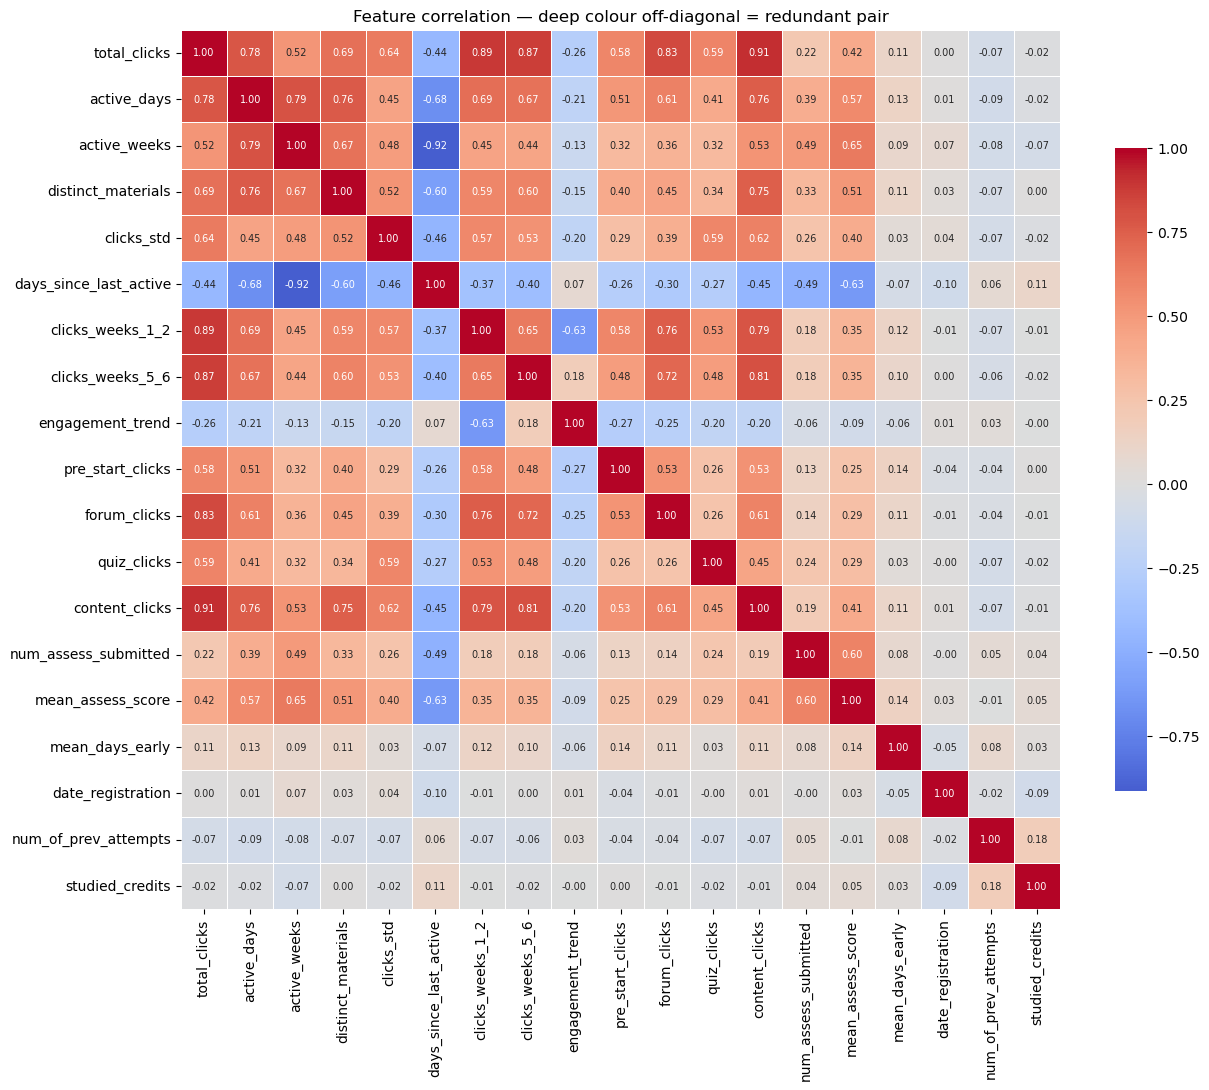

In [6]:
import seaborn as sns

corr = features[FEATURE_COLS].corr()
plt.figure(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7})
plt.title("Feature correlation — deep colour off-diagonal = redundant pair")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

**Relevance bar** = how strongly each feature correlates with `at_risk`. Bars near zero carry little signal.

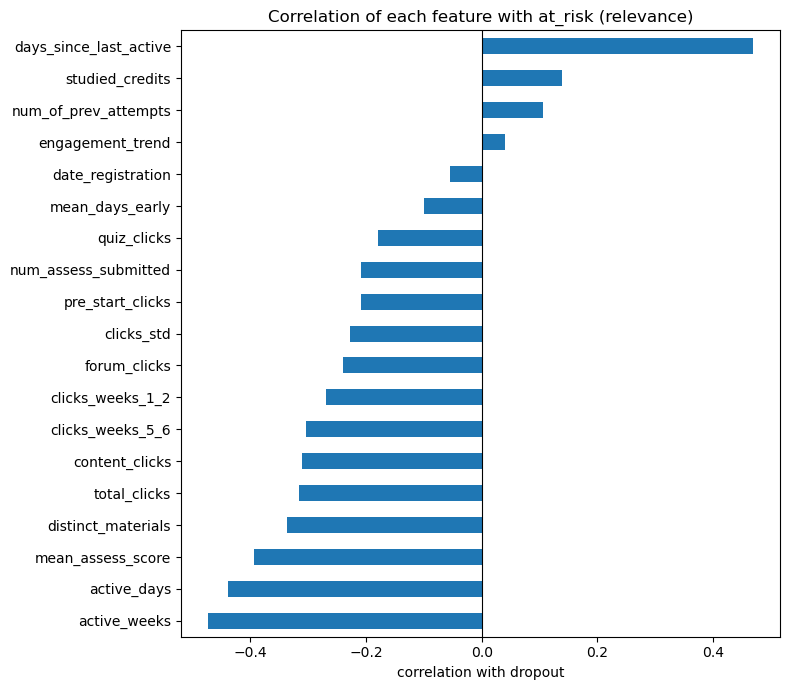

active_weeks             -0.473320
active_days              -0.438598
mean_assess_score        -0.393862
distinct_materials       -0.337603
total_clicks             -0.316553
content_clicks           -0.311416
clicks_weeks_5_6         -0.304153
clicks_weeks_1_2         -0.270127
forum_clicks             -0.240080
clicks_std               -0.227175
pre_start_clicks         -0.208539
num_assess_submitted     -0.208244
quiz_clicks              -0.178778
mean_days_early          -0.099542
date_registration        -0.054123
engagement_trend          0.039842
num_of_prev_attempts      0.105460
studied_credits           0.138630
days_since_last_active    0.468793
Name: at_risk, dtype: float64

In [7]:
target_corr = (features[FEATURE_COLS + ["at_risk"]].corr()["at_risk"]
               .drop("at_risk").sort_values())
plt.figure(figsize=(8, 7))
target_corr.plot(kind="barh")
plt.title("Correlation of each feature with at_risk (relevance)")
plt.xlabel("correlation with dropout")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("target_correlation.png", dpi=150)
plt.show()
target_corr

## Step 3 — Compare feature sets (cross-validated)

The charts above are *clues*; this is the *test*. We cross-validate a lean **core** set against core + each borderline add-on, and against the full 19. We use **5-fold CV** (split the data 5 ways, train on 4 score on 1, rotate, average) and compare by **ROC-AUC** (threshold-free, so it isolates the features).

The `std` column is the run-to-run wobble: **if an add-on's AUC gain is smaller than the std, it's noise — drop it.**

This uses Random Forest just to rank the feature sets. The full 3-model showdown is the next notebook.

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

y = features["at_risk"]

# Lean core: strong + non-redundant (edit freely)
core = ["days_since_last_active", "active_days", "distinct_materials",
        "mean_assess_score", "clicks_std", "quiz_clicks", "clicks_weeks_5_6"]

# Borderline features we want to test
addons = ["num_assess_submitted", "pre_start_clicks",
          "studied_credits", "num_of_prev_attempts"]

variants = {
    "core (7)": core,
    "core + num_assess_submitted": core + ["num_assess_submitted"],
    "core + pre_start_clicks":     core + ["pre_start_clicks"],
    "core + studied_credits":      core + ["studied_credits"],
    "core + num_of_prev_attempts": core + ["num_of_prev_attempts"],
    "core + all 4 add-ons":        core + addons,
    "full (19)":                   FEATURE_COLS,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, cols in variants.items():
    model = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
    auc = cross_val_score(model, features[cols], y, cv=cv, scoring="roc_auc")
    rec = cross_val_score(model, features[cols], y, cv=cv, scoring="recall")
    rows.append({"variant": name, "n_features": len(cols),
                 "AUC_mean": auc.mean(), "AUC_std": auc.std(),
                 "Recall_mean": rec.mean(), "Recall_std": rec.std()})

results = pd.DataFrame(rows).set_index("variant").round(4)
results

,n_features,AUC_mean,AUC_std,Recall_mean,Recall_std
variant,,,,,
core (7),7,0.8166,0.0033,0.7162,0.0075
core + num_assess_submitted,8,0.8212,0.0034,0.7171,0.0053
core + pre_start_clicks,8,0.8196,0.0034,0.7156,0.0089
core + studied_credits,8,0.8273,0.0030,0.7159,0.0079
core + num_of_prev_attempts,8,0.8197,0.0034,0.7176,0.0066
core + all 4 add-ons,11,0.8332,0.0039,0.7200,0.0075
full (19),19,0.8427,0.0029,0.7304,0.0083


---
### Next step
Run `task2_model_comparison.ipynb` for the full 3-model showdown across the shortlisted feature sets.